In [2]:
import qiskit as qsk
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt
from qiskit.visualization import plot_histogram 


In [ ]:
# create the circuit and extract the distribution of the numbers 
# for this example we will use 4 qbits

# second 4 is for the number of classical bits 
# (4, 4) means we measure of 4 of the quantum qbits (as there also exists partial measurements)
circuit = qsk.QuantumCircuit(4, 4)

# apply for each qbit a hadamard and a measurement gate
for i in range(4):
    circuit.h(i)
circuit.measure([*range(4)], [*range(4)])

# init the simulator and transpile the circuit (optimize it for the specific simulator)
simulator = AerSimulator()
transpiled_circ = qsk.transpile(circuit, simulator)

# results = simulator.run(transpiled_circ, shots=1).result()
# count = results.get_counts()
# print(f"Measurement {count}")


{'1101': 48, '1011': 60, '0011': 79, '0111': 65, '1110': 45, '1100': 61, '0110': 66, '1000': 78, '0101': 64, '1001': 55, '0100': 52, '0001': 63, '1111': 70, '0010': 73, '0000': 64, '1010': 57}


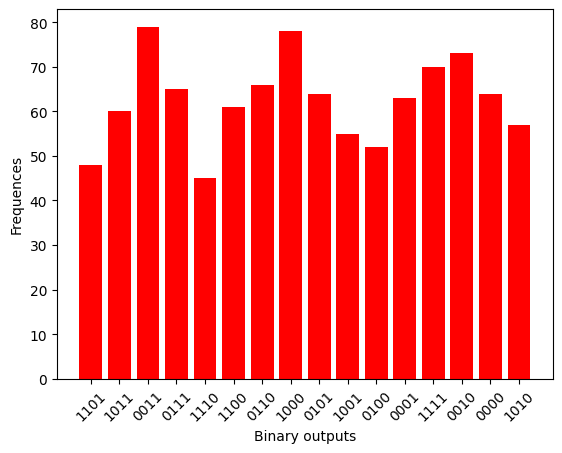

{'1011': 594, '0000': 632, '1100': 575, '0001': 668, '1111': 588, '1110': 625, '1001': 603, '0101': 640, '0011': 627, '0111': 621, '1010': 649, '0010': 614, '1000': 641, '0110': 656, '1101': 659, '0100': 608}


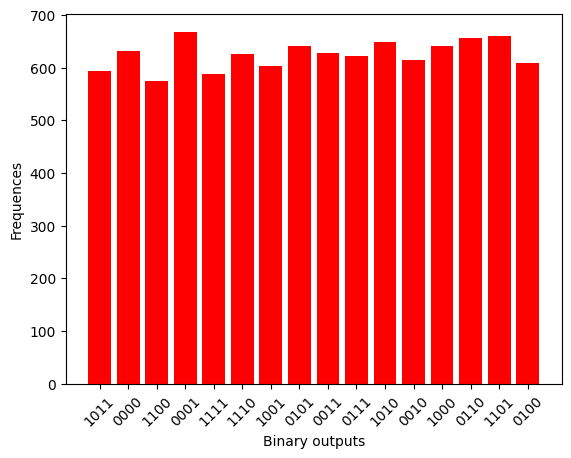

{'1101': 6312, '0000': 6283, '0010': 6037, '0001': 6261, '1111': 6279, '1000': 6393, '0110': 6226, '1110': 6291, '1010': 6331, '1011': 6206, '0111': 6276, '0011': 6218, '0101': 6285, '1001': 6203, '1100': 6205, '0100': 6194}


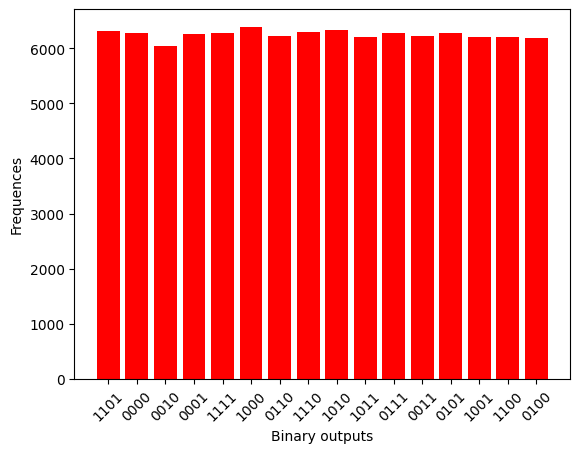

{'1010': 61998, '0010': 62577, '1011': 62277, '0011': 62665, '0111': 63024, '0100': 62586, '1100': 62202, '0101': 62851, '1001': 62257, '1111': 62403, '0001': 62408, '1000': 62326, '0110': 62461, '1101': 62673, '0000': 62770, '1110': 62522}


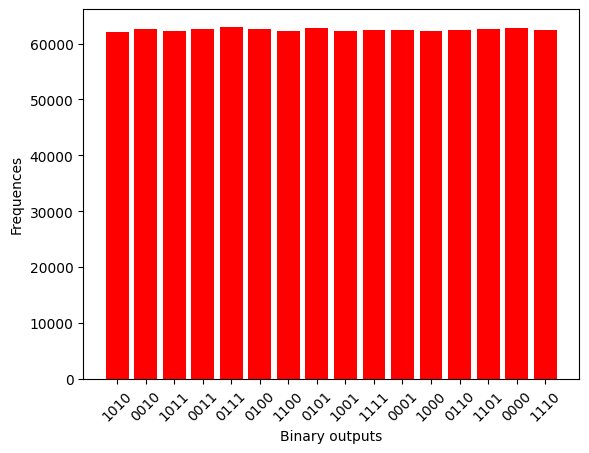

In [6]:
# sampling the circuit for a number of 100.000 to test the distribution it creates

# results = simulator.run(transpiled_circ, shots=1000).result()
# counts = results.get_counts()
# print(counts)
# plot_histogram(counts)
for i in [1000, 10000, 100000, 1000000]:       
    results = simulator.run(transpiled_circ, shots=i).result()
    counts = results.get_counts()
    freqs = counts.values()
    keys = counts.keys()

    print(counts)
    plt.bar(keys, freqs, color='red')
    plt.xlabel('Binary outputs')
    plt.ylabel('Frequences')
    plt.xticks(rotation=45)
    plt.show()


# as demonstrated below based on the theory of big numbers the distribution that gets generated
# after the circuit is executed on a different number of trials is getting more and more to a 
# uniform distribution => we can use the circuit to truely generate a random number 